**IMPORT LIBRARIES**


    NetworkX is for network/graph analysis, Matplotlib is for plotting

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.approximation import traveling_salesman_problem
import random

**UNDIRECTED GRAPH (Bidirectional roads)**

    Undirected graph = roads are bidirectional

**Create an empty undirected graph**

In [3]:
G_undirected = nx.Graph()

**Add cities as nodes**

    Each node represents a city

In [4]:
cities = ["Delhi", "Mumbai", "Chennai", "Kolkata", "Bangalore", "Hyderabad", "Pune", "Jaipur"]
G_undirected.add_nodes_from(cities)

**Add edges with distance as weight**

    Edge represents road, weight represents distance in km

In [5]:
G_undirected.add_edge("Delhi", "Jaipur", weight=280)
G_undirected.add_edge("Delhi", "Mumbai", weight=1400)
G_undirected.add_edge("Delhi", "Kolkata", weight=1500)
G_undirected.add_edge("Mumbai", "Pune", weight=150)
G_undirected.add_edge("Mumbai", "Bangalore", weight=980)
G_undirected.add_edge("Bangalore", "Chennai", weight=350)
G_undirected.add_edge("Hyderabad", "Bangalore", weight=570)
G_undirected.add_edge("Hyderabad", "Chennai", weight=630)
G_undirected.add_edge("Kolkata", "Chennai", weight=1650)

Visualization of undirected network

    Spring layout distributes nodes for clear visualization

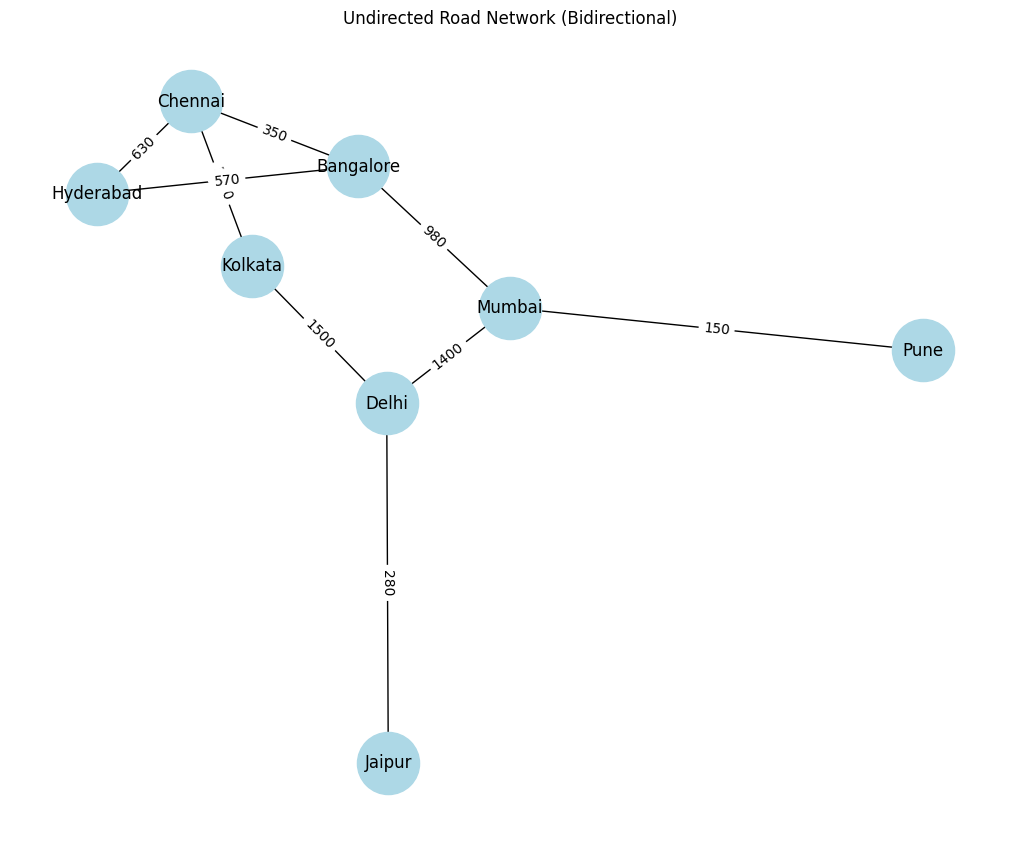

In [6]:
plt.figure(figsize=(10,8))
pos = nx.spring_layout(G_undirected, seed=42)
nx.draw(G_undirected, pos, with_labels=True, node_size=2000, node_color="lightblue")
labels = nx.get_edge_attributes(G_undirected, 'weight')
nx.draw_networkx_edge_labels(G_undirected, pos, edge_labels=labels)
plt.title("Undirected Road Network (Bidirectional)")
plt.show()

**Print basic information**

In [7]:
print("Cities:", G_undirected.nodes())  # Nodes
print("Roads:", G_undirected.edges(data=True))  # Edges with weights
print("Is network connected?:", nx.is_connected(G_undirected))  # Connectivity check

Cities: ['Delhi', 'Mumbai', 'Chennai', 'Kolkata', 'Bangalore', 'Hyderabad', 'Pune', 'Jaipur']
Roads: [('Delhi', 'Jaipur', {'weight': 280}), ('Delhi', 'Mumbai', {'weight': 1400}), ('Delhi', 'Kolkata', {'weight': 1500}), ('Mumbai', 'Pune', {'weight': 150}), ('Mumbai', 'Bangalore', {'weight': 980}), ('Chennai', 'Bangalore', {'weight': 350}), ('Chennai', 'Hyderabad', {'weight': 630}), ('Chennai', 'Kolkata', {'weight': 1650}), ('Bangalore', 'Hyderabad', {'weight': 570})]
Is network connected?: True


**Shortest path using Dijkstra's algorithm**

    Finds minimum distance path between two cities

In [ ]:
source = "Delhi"
destination = "Chennai"
shortest_path = nx.dijkstra_path(G_undirected, source, destination)
shortest_distance = nx.dijkstra_path_length(G_undirected, source, destination)
print("\nUndirected Graph Shortest Path from Delhi to Chennai:", shortest_path)
print("Distance:", shortest_distance, "km")

**Visualize shortest path**

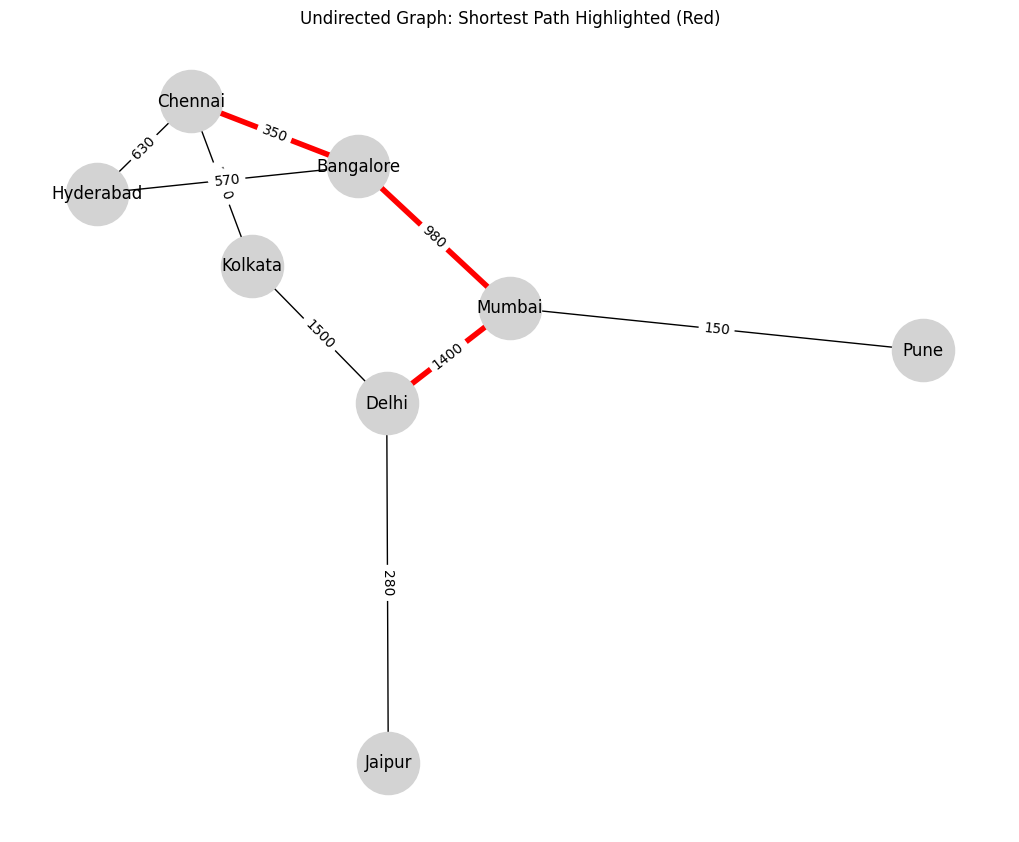

In [8]:
path_edges = list(zip(shortest_path, shortest_path[1:]))
plt.figure(figsize=(10,8))
nx.draw(G_undirected, pos, with_labels=True, node_color="lightgray", node_size=2000)
nx.draw_networkx_edges(G_undirected, pos, edgelist=path_edges, width=4, edge_color="red")
nx.draw_networkx_edge_labels(G_undirected, pos, edge_labels=labels)
plt.title("Undirected Graph: Shortest Path Highlighted (Red)")
plt.show()

**Centrality measures**

    Measure importance of each node

In [9]:
degree_centrality = nx.degree_centrality(G_undirected)
betweenness_centrality = nx.betweenness_centrality(G_undirected)
print("\nDegree Centrality (Undirected):", degree_centrality)
print("\nBetweenness Centrality (Undirected):", betweenness_centrality)


Degree Centrality (Undirected): {'Delhi': 0.42857142857142855, 'Mumbai': 0.42857142857142855, 'Chennai': 0.42857142857142855, 'Kolkata': 0.2857142857142857, 'Bangalore': 0.42857142857142855, 'Hyderabad': 0.2857142857142857, 'Pune': 0.14285714285714285, 'Jaipur': 0.14285714285714285}

Betweenness Centrality (Undirected): {'Delhi': 0.38095238095238093, 'Mumbai': 0.42857142857142855, 'Chennai': 0.14285714285714285, 'Kolkata': 0.14285714285714285, 'Bangalore': 0.23809523809523808, 'Hyderabad': 0.0, 'Pune': 0.0, 'Jaipur': 0.0}


**Traveling Salesman Problem (TSP)**

    Find shortest route visiting all cities once

In [10]:
tsp_path = traveling_salesman_problem(G_undirected, weight="weight")
print("\nTSP Route (Undirected):", tsp_path)


TSP Route (Undirected): ['Delhi', 'Kolkata', 'Chennai', 'Bangalore', 'Hyderabad', 'Bangalore', 'Mumbai', 'Pune', 'Mumbai', 'Delhi', 'Jaipur', 'Delhi']


**Visualize TSP path**

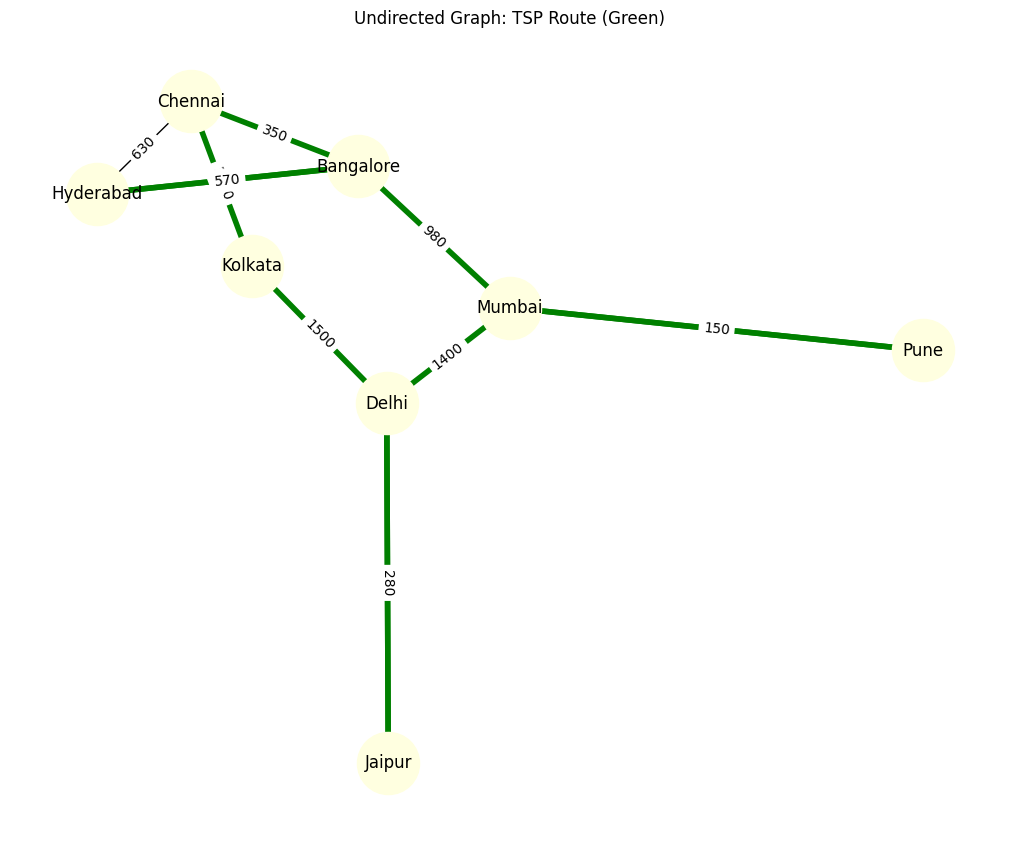

In [11]:
tsp_edges = list(zip(tsp_path, tsp_path[1:]))
plt.figure(figsize=(10,8))
nx.draw(G_undirected, pos, with_labels=True, node_color="lightyellow", node_size=2000)
nx.draw_networkx_edges(G_undirected, pos, edgelist=tsp_edges, width=4, edge_color="green")
nx.draw_networkx_edge_labels(G_undirected, pos, edge_labels=labels)
plt.title("Undirected Graph: TSP Route (Green)")
plt.show()

**DIRECTED GRAPH (One-way roads)**

    Directed graph = roads have direction (one-way)

Create empty directed graph

In [12]:
G_directed = nx.DiGraph()

**Add same cities as nodes**

In [13]:
G_directed.add_nodes_from(cities)

**Add directed edges (one-way roads)**

In [14]:
G_directed.add_edge("Delhi", "Jaipur", weight=280)
G_directed.add_edge("Delhi", "Mumbai", weight=1400)
G_directed.add_edge("Mumbai", "Pune", weight=150)
G_directed.add_edge("Pune", "Mumbai", weight=150)  # Bidirectional by reverse edge
G_directed.add_edge("Mumbai", "Bangalore", weight=980)
G_directed.add_edge("Bangalore", "Chennai", weight=350)
G_directed.add_edge("Hyderabad", "Bangalore", weight=570)
G_directed.add_edge("Chennai", "Hyderabad", weight=630)
G_directed.add_edge("Kolkata", "Chennai", weight=1650)

**Visualization of directed network**

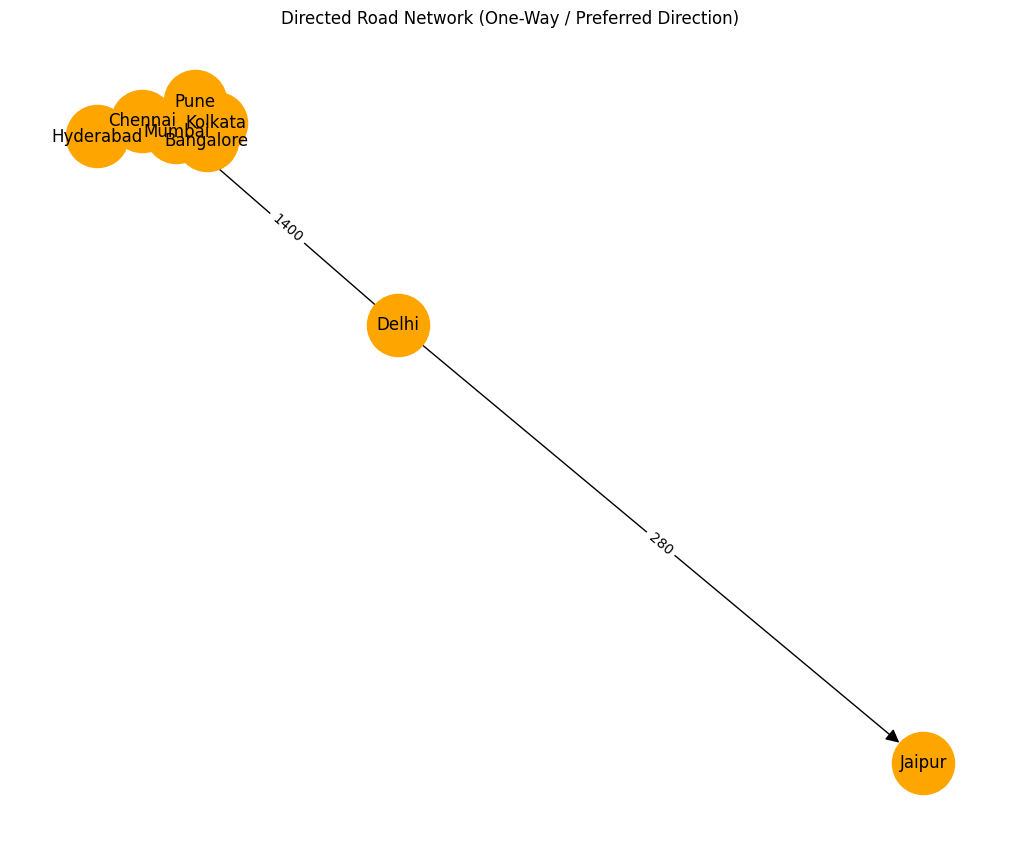

In [15]:
plt.figure(figsize=(10,8))
pos = nx.spring_layout(G_directed, seed=42)
nx.draw(G_directed, pos, with_labels=True, node_size=2000, node_color="orange", arrowsize=20, arrowstyle='-|>')
labels_dir = nx.get_edge_attributes(G_directed, 'weight')
nx.draw_networkx_edge_labels(G_directed, pos, edge_labels=labels_dir)
plt.title("Directed Road Network (One-Way / Preferred Direction)")
plt.show()

**Shortest path in directed graph (Dijkstra)**

In [16]:
shortest_path_dir = nx.dijkstra_path(G_directed, source, destination)
shortest_distance_dir = nx.dijkstra_path_length(G_directed, source, destination)
print("\nDirected Graph Shortest Path from Delhi to Chennai:", shortest_path_dir)
print("Distance:", shortest_distance_dir, "km")


Directed Graph Shortest Path from Delhi to Chennai: ['Delhi', 'Mumbai', 'Bangalore', 'Chennai']
Distance: 2730 km


**Visualize shortest path in directed graph**

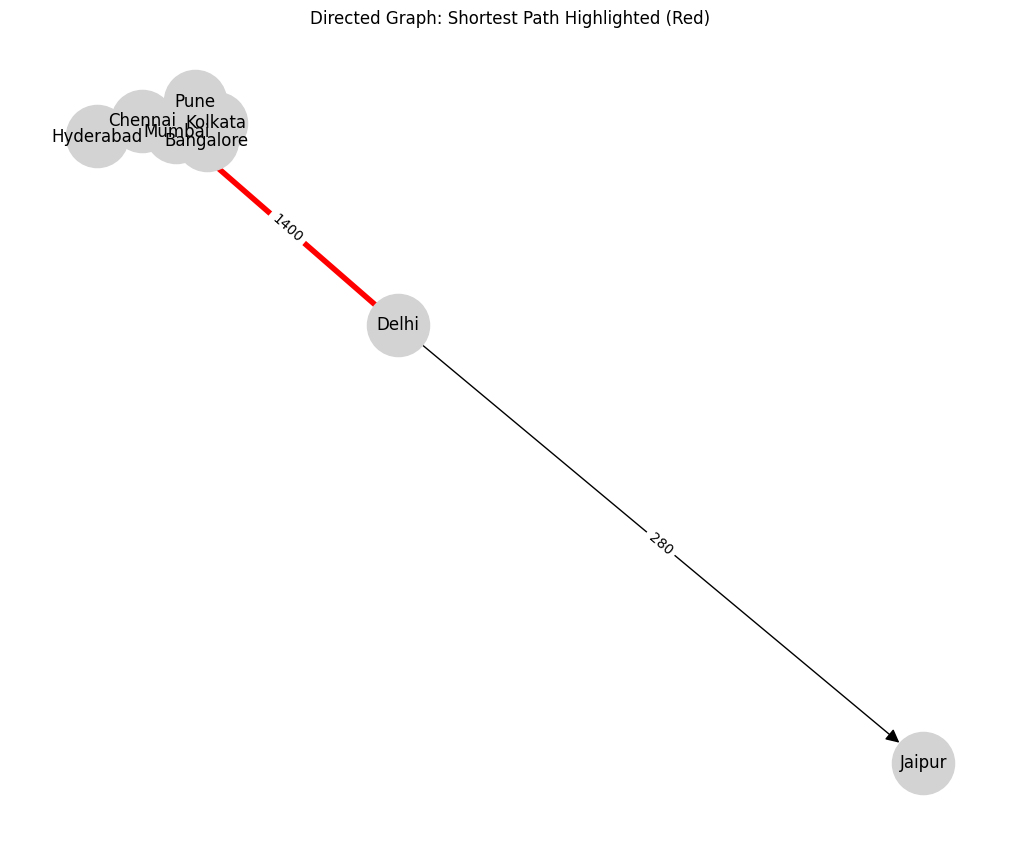

In [17]:
path_edges_dir = list(zip(shortest_path_dir, shortest_path_dir[1:]))
plt.figure(figsize=(10,8))
nx.draw(G_directed, pos, with_labels=True, node_color="lightgray", node_size=2000, arrowsize=20)
nx.draw_networkx_edges(G_directed, pos, edgelist=path_edges_dir, width=4, edge_color="red", arrowstyle='-|>')
nx.draw_networkx_edge_labels(G_directed, pos, edge_labels=labels_dir)
plt.title("Directed Graph: Shortest Path Highlighted (Red)")
plt.show()

**Degree and centrality for directed graph**

    In-degree = number of incoming edges
    Out-degree = number of outgoing edges

In [18]:
in_degree = G_directed.in_degree()
out_degree = G_directed.out_degree()
print("\nIn-Degree of cities (Directed):", dict(in_degree))
print("\nOut-Degree of cities (Directed):", dict(out_degree))


In-Degree of cities (Directed): {'Delhi': 0, 'Mumbai': 2, 'Chennai': 2, 'Kolkata': 0, 'Bangalore': 2, 'Hyderabad': 1, 'Pune': 1, 'Jaipur': 1}

Out-Degree of cities (Directed): {'Delhi': 2, 'Mumbai': 2, 'Chennai': 1, 'Kolkata': 1, 'Bangalore': 1, 'Hyderabad': 1, 'Pune': 1, 'Jaipur': 0}


**Centrality for directed graph**

In [19]:
degree_centrality_dir = nx.degree_centrality(G_directed)
betweenness_centrality_dir = nx.betweenness_centrality(G_directed)
print("\nDegree Centrality (Directed):", degree_centrality_dir)
print("\nBetweenness Centrality (Directed):", betweenness_centrality_dir)


Degree Centrality (Directed): {'Delhi': 0.2857142857142857, 'Mumbai': 0.5714285714285714, 'Chennai': 0.42857142857142855, 'Kolkata': 0.14285714285714285, 'Bangalore': 0.42857142857142855, 'Hyderabad': 0.2857142857142857, 'Pune': 0.2857142857142857, 'Jaipur': 0.14285714285714285}

Betweenness Centrality (Directed): {'Delhi': 0.0, 'Mumbai': 0.16666666666666666, 'Chennai': 0.14285714285714285, 'Kolkata': 0.0, 'Bangalore': 0.16666666666666666, 'Hyderabad': 0.047619047619047616, 'Pune': 0.0, 'Jaipur': 0.0}


**SUMMARY COMPARISON: DIRECTED vs UNDIRECTED ROAD NETWORK**

Undirected Graph:
Number of cities (nodes): 8
Number of roads (edges): 9
Is connected?: True
Average degree: 2.25

Directed Graph:
Number of cities (nodes): 8
Number of roads (edges): 9
Is strongly connected?: False
Average in-degree: 1.125
Average out-degree: 1.125

Centrality Comparison (Degree):
Undirected Degree Centrality: {'Delhi': 0.42857142857142855, 'Mumbai': 0.42857142857142855, 'Chennai': 0.42857142857142855, 'Kolkata': 0.2857142857142857, 'Bangalore': 0.42857142857142855, 'Hyderabad': 0.2857142857142857, 'Pune': 0.14285714285714285, 'Jaipur': 0.14285714285714285}
Directed Degree Centrality: {'Delhi': 0.2857142857142857, 'Mumbai': 0.5714285714285714, 'Chennai': 0.42857142857142855, 'Kolkata': 0.14285714285714285, 'Bangalore': 0.42857142857142855, 'Hyderabad': 0.2857142857142857, 'Pune': 0.2857142857142857, 'Jaipur': 0.14285714285714285}

Centrality Comparison (Betweenness):
Undirected Betweenness Centrality: {'Delhi': 0.38095238095238093, 'Mumbai': 0.42857142857142855, 'Chen

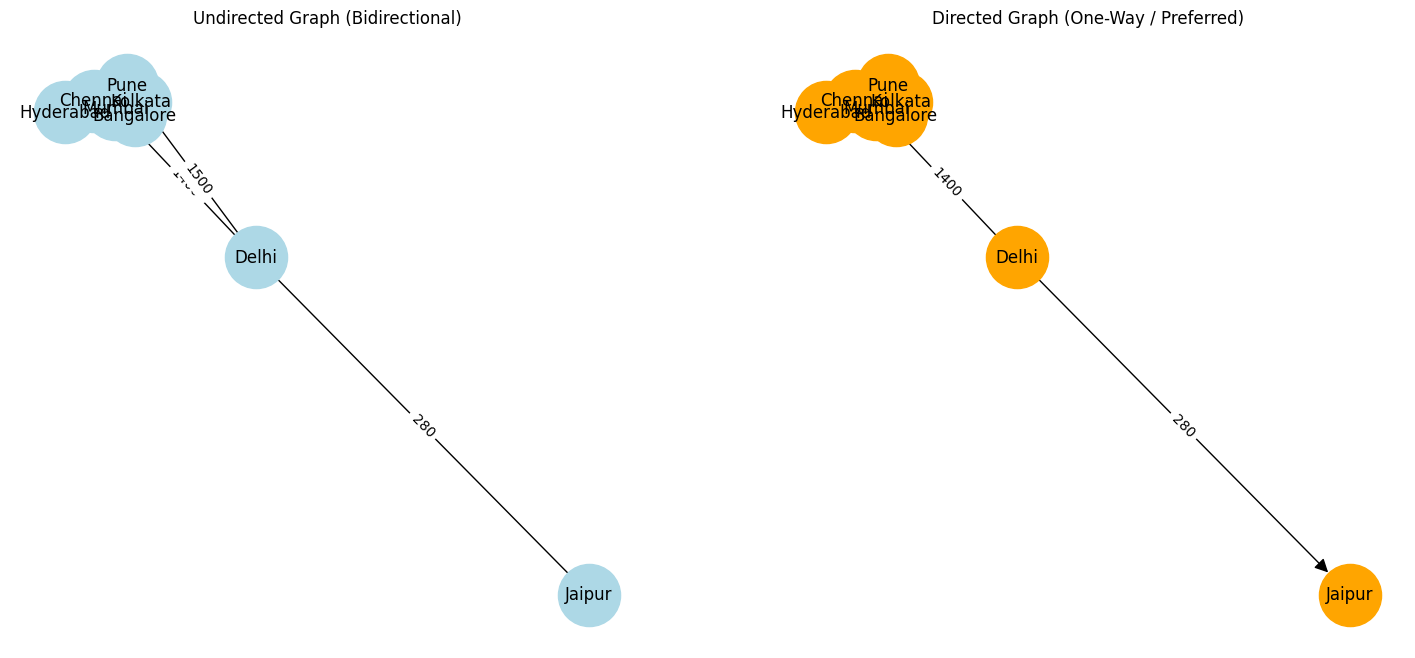


Summary Table:

            Parameter Undirected Directed
0               Nodes          8        8
1               Edges          9        9
2           Connected       True    False
3      Average Degree       2.25        -
4   Average In-Degree          -     1.12
5  Average Out-Degree          -     1.12


In [20]:
# -----------------------------
# 1. Basic Parameters
# -----------------------------
print("Undirected Graph:")
print("Number of cities (nodes):", G_undirected.number_of_nodes())
print("Number of roads (edges):", G_undirected.number_of_edges())
print("Is connected?:", nx.is_connected(G_undirected))
print("Average degree:", sum(dict(G_undirected.degree()).values()) / G_undirected.number_of_nodes())

print("\nDirected Graph:")
print("Number of cities (nodes):", G_directed.number_of_nodes())
print("Number of roads (edges):", G_directed.number_of_edges())
print("Is strongly connected?:", nx.is_strongly_connected(G_directed))
print("Average in-degree:", sum(dict(G_directed.in_degree()).values()) / G_directed.number_of_nodes())
print("Average out-degree:", sum(dict(G_directed.out_degree()).values()) / G_directed.number_of_nodes())


# -----------------------------
# 2. Centrality Comparison
# -----------------------------
print("\nCentrality Comparison (Degree):")
print("Undirected Degree Centrality:", degree_centrality)
print("Directed Degree Centrality:", degree_centrality_dir)

print("\nCentrality Comparison (Betweenness):")
print("Undirected Betweenness Centrality:", betweenness_centrality)
print("Directed Betweenness Centrality:", betweenness_centrality_dir)


# -----------------------------
# 3. Visualization Side by Side
# -----------------------------

plt.figure(figsize=(18,8))

# Undirected Graph on Left
plt.subplot(1,2,1)
nx.draw(G_undirected, pos, with_labels=True, node_color="lightblue", node_size=2000)
nx.draw_networkx_edge_labels(G_undirected, pos, edge_labels=labels)
plt.title("Undirected Graph (Bidirectional)")

# Directed Graph on Right
plt.subplot(1,2,2)
nx.draw(G_directed, pos, with_labels=True, node_color="orange", node_size=2000, arrowsize=20, arrowstyle='-|>')
nx.draw_networkx_edge_labels(G_directed, pos, edge_labels=labels_dir)
plt.title("Directed Graph (One-Way / Preferred)")

plt.show()


# -----------------------------
# 4. Summary Table of Parameters (Optional)
# -----------------------------

import pandas as pd

summary_table = pd.DataFrame({
    "Parameter": ["Nodes", "Edges", "Connected", "Average Degree", "Average In-Degree", "Average Out-Degree"],
    "Undirected": [G_undirected.number_of_nodes(),
                   G_undirected.number_of_edges(),
                   nx.is_connected(G_undirected),
                   round(sum(dict(G_undirected.degree()).values()) / G_undirected.number_of_nodes(),2),
                   "-", "-"],
    "Directed": [G_directed.number_of_nodes(),
                 G_directed.number_of_edges(),
                 nx.is_strongly_connected(G_directed),
                 "-",
                 round(sum(dict(G_directed.in_degree()).values()) / G_directed.number_of_nodes(),2),
                 round(sum(dict(G_directed.out_degree()).values()) / G_directed.number_of_nodes(),2)]
})

print("\nSummary Table:\n")
print(summary_table)